# Milestone 2 Notebook
Authors: Kshitij Sharma, Elouann Lucas

## Milestone 1 summary - dataset preparation and exploration

Dataset collection is done in the [preprocess](preprocess.ipynb) notebook.

Feature engineering and extraction is done in the [stats computation](stats_computation.ipynb) notebook.

### Feature Analysis

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd 
import os

data_path = os.path.join(os.getcwd(), '..', 'data', 'geojson', 'train_files.geojson')

train_gdf = gpd.read_file(data_path)
features = ['r_mean','r_median', 'r_std','r_var', 'g_mean','g_median', 'g_std','g_var', 'b_mean','b_median','b_var', 'b_std']

print("Feature Statistics:")
print(train_gdf[features].describe())

Feature Statistics:
            r_mean     r_median        r_std        r_var       g_mean  \
count  1542.000000  1542.000000  1542.000000  1542.000000  1542.000000   
mean    127.407164   130.043450    44.365438  2177.660223   133.902864   
std      42.432392    50.241287    14.474252  1411.212529    37.970571   
min      14.052425     9.000000     9.624962    92.639891    16.971166   
25%      94.888207    91.000000    33.531380  1124.353434   108.241515   
50%     121.219682   120.500000    42.414521  1798.991583   128.707001   
75%     153.807830   159.000000    53.584606  2871.309950   155.381226   
max     244.339260   255.000000    90.384147  8169.294104   246.924832   

          g_median        g_std        g_var       b_mean     b_median  \
count  1542.000000  1542.000000  1542.000000  1542.000000  1542.000000   
mean    136.926394    41.242705  1897.844081   104.532593   104.860895   
std      44.859373    14.036064  1307.325053    50.285613    59.635541   
min      11.00000

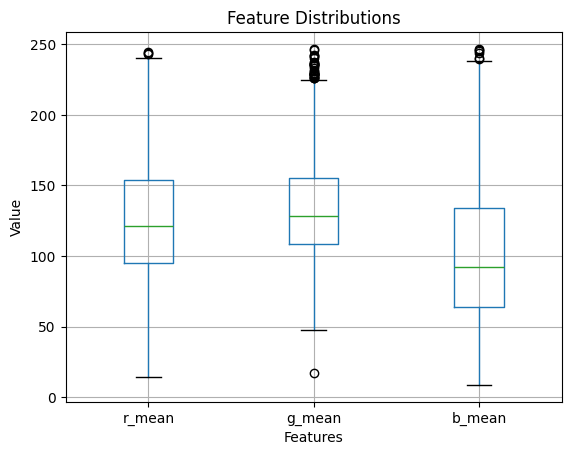

In [8]:
display_features = ['r_mean','g_mean','b_mean']

train_gdf[display_features].boxplot()
plt.title('Feature Distributions')
plt.ylabel('Value')
plt.xlabel('Features')
plt.show()

On this box plot showing the distribution of `r_mean`, `g_mean`, and `b_mean` values, we can observe that the dataset tends towards lower blue mean values, indicating that the rasters in our dataset have less blue reflectance. This could be due to the prevalence of vegetation and soil, which typically reflect more in the red and green bands.

To get more insights, we will later see how these features correlate with each other and with the target variable (land cover classes).

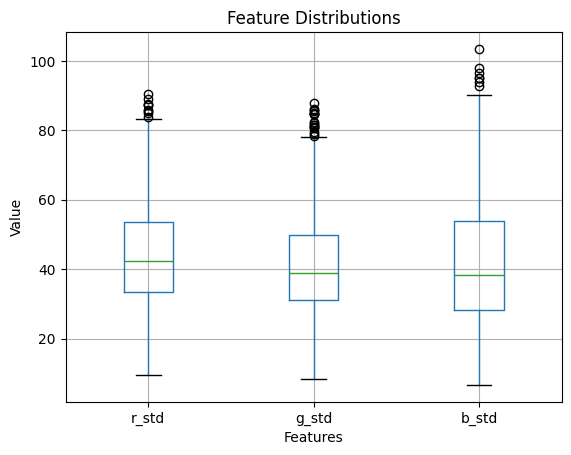

In [ ]:
display_features = ['r_std','g_std','b_std']

train_gdf[display_features].boxplot()
plt.title('Feature Distributions')
plt.ylabel('Value')
plt.xlabel('Features')
plt.show()

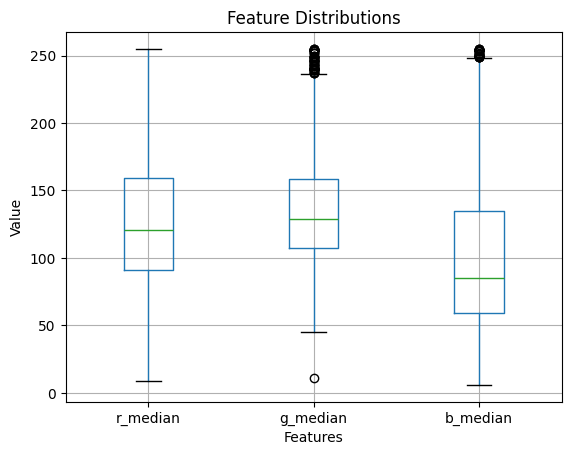

In [ ]:
display_features = ['r_median','g_median','b_median']

train_gdf[display_features].boxplot()
plt.title('Feature Distributions')
plt.ylabel('Value')
plt.xlabel('Features')
plt.show()

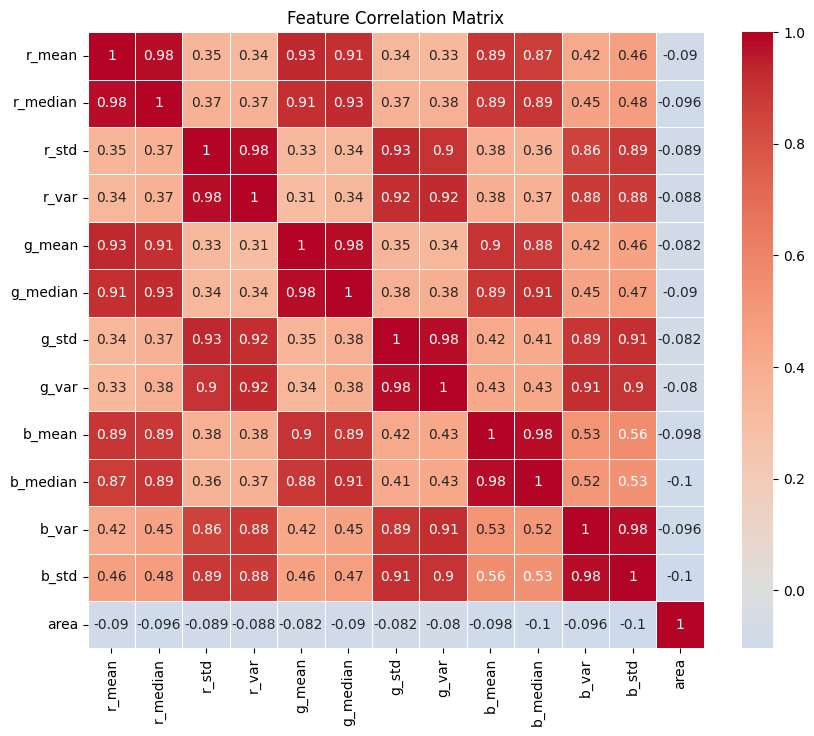

In [ ]:
# correlation 
plt.figure(figsize=(10, 8))
correlation_matrix = train_gdf[features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

Here the correlation between `r_mean` and `g_mean` is very high : almost identical , similar to `r_mean` and `b_mean` . All RGB bands are highly redundant , they don't provide much value, however, the `area` contains extremely crucial information as it is calculated from geometric properties instead of optical. For future work we would look into extraction of geometric features or look into HSV , LAB colors.. Other statstics that can disguinsh them properly or only using some of them or using some vegetation indexes.

## Observed noise
By plotting the histogram of the pixel values of the images, we can observe that there is a significant amount of noise in the images. 
This noise is inherrent to the drone images and is not due to any preprocessing steps.
This noise can be observed in the histogram as a large number of pixel values that are close to zero.

(3, 17715, 18898)
{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': 0.0, 'width': 18898, 'height': 17715, 'count': 3, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 18N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-75],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32618"]]'), 'transform': Affine(0.036980000000000006, 0.0, 423877.12314000004,
       0.0, -0.036980000000000006, 529830.8609300001), 'blockxsize': 512, 'blockysize': 512, 'tiled': True, 'compress': 'YCbCr JPEG', 'interleave': 'pixel', 'photometric': 'ycbcr'}


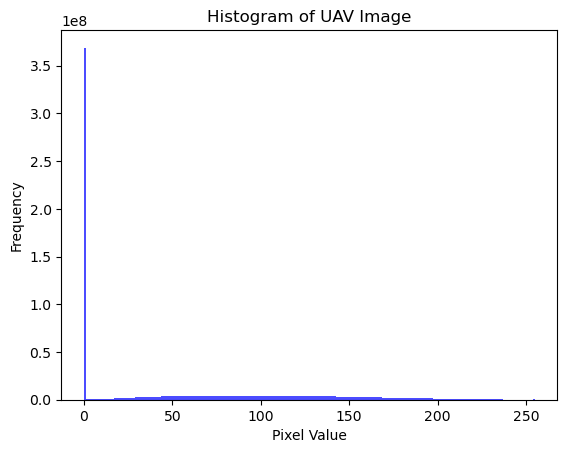

In [ ]:
import matplotlib.pyplot as plt
import rasterio
import os 
cwd = os.getcwd()

# Loading a sample UAV image directly from the data folder
# Should be replaced with cog file
path = os.path.join(cwd,'..','data', 'images', '6539ab40965ddd0001ee8588.tif')

with rasterio.open(path) as src:
    uav_image = src.read()  # Lecture de toutes les bandes
    print(uav_image.shape)   # Dimensions (bandes, hauteur, largeur)
    print(src.profile)  # Métadonnées   


plt.hist(uav_image.ravel(), bins=256, color='blue', alpha=0.7)
plt.title('Histogram of UAV Image')
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.show()

### New steps conducted after Milestone 1
After the feedback received during Milestone 1, we made the following changes to our dataset preparation process:
1.  Reduced the amount of categories by merging them using the level 2 [corine land cover legend](../docs/CLC_Legend_EN.pdf) (from level 3), which gives us a total of 10 classes instead of 24
2.  Cleaned polygons by merging the multi-polygons corresponding to the same sample into one polygon, this process is done in the [clean polygons](clean_polygons.ipynb) notebook.
3.  Splitted the dataset into training and test using stratifed sampling to ensure that all classes are represented in both sets, this process is done in the [train test split](train_test_split.ipynb) notebook.

## Milestone 2 - Model training and evaluation

Define features columns and target column

In [6]:
features = ['r_mean','r_median', 'r_std','r_var', 'g_mean','g_median', 'g_std','g_var', 'b_mean','b_median','b_var', 'b_std','area']
target = 'OBSERV_GROUP'

label_map = {
    '0' : 'Building',
    '11' : 'Urban',
    '12' : 'Highway',
    '21' : 'Seasonal crops',
    '22' : 'Permanent crops',
    '23' : 'Pasture',
    '31' : 'Forest',
    '32' : 'Grassland',
    '33' : 'Bare areas',
    '51' : 'Water'
}

Load the splits

In [7]:
train_gdf = gpd.read_file(os.path.join(os.getcwd(),'..','data','geojson','train_files.geojson'))

test_gdf = gpd.read_file(os.path.join(os.getcwd(),'..','data','geojson','test_files.geojson'))

In [8]:
train_gdf

,CODIGO,OBSERV,INSUMO,APOYO,ASIGNACION,Asignado,OAM,area,url_type,download_url,...,g_mean,g_median,g_std,g_var,b_mean,b_median,b_std,b_var,CODIGO_GROUP,geometry
0,0,building,Map1_Orthomosaic_ThuJul24202452191338,None,Sofia,None,https://drive.google.com/drive/folders/1PoaKqU...,54.139512,gdrive,https://drive.google.com/file/d/1T1Pin5cXsCcu4...,...,205.605074,227.0,54.732962,2995.697165,190.791912,214.0,61.152457,3739.622993,0,"POLYGON ((-73.24313 11.25111, -73.24314 11.251..."
1,0,building,961,None,Sofia,None,https://map.openaerialmap.org/#/-77.4261206388...,104.680054,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,128.036882,129.0,65.329558,4267.951132,117.081532,107.0,81.185142,6591.027328,0,"POLYGON ((-77.42661 1.04871, -77.42669 1.04872..."
2,112,urban not continuous,MapPlan_Orthomosaic_ThuJul24202849972911,None,Sofia,None,https://drive.google.com/drive/folders/1QRkuTF...,283.000199,gdrive,https://drive.google.com/file/d/1uDznoDuGo5OsS...,...,176.645139,207.0,77.495977,6005.626445,178.040137,217.0,82.348225,6781.230110,11,"POLYGON ((-72.26548 11.36997, -72.26549 11.369..."
3,22,permanent crops,Santa Rosa,None,None,Juan,https://map.openaerialmap.org/#/-76.5763378143...,14940.149489,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,109.128906,109.0,39.064442,1526.030626,58.886060,54.0,35.320168,1247.514251,22,"POLYGON ((-76.57316 1.70816, -76.57307 1.70812..."
4,22,permanent crops,1175,None,Sofia,None,https://map.openaerialmap.org/#/-75.6697082519...,3840.901611,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,123.623597,130.0,36.791095,1353.584665,77.938724,78.0,32.494331,1055.881557,22,"POLYGON ((-75.67163 6.19024, -75.67151 6.19028..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1537,0,building,MapPlan_Orthomosaic_ThuJul24202849972911,None,Sofia,None,https://drive.google.com/drive/folders/1QRkuTF...,24.848614,gdrive,https://drive.google.com/file/d/1uDznoDuGo5OsS...,...,219.875190,247.0,53.746206,2888.654662,214.689229,249.0,64.765523,4194.572925,0,"POLYGON ((-72.26377 11.37022, -72.2638 11.3702..."
1538,0,building,1175,None,Sofia,None,https://map.openaerialmap.org/#/-75.6697082519...,278.316951,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,132.139372,133.0,31.927362,1019.356443,89.507846,87.0,28.383239,805.608281,0,"POLYGON ((-75.67342 6.19721, -75.67361 6.19716..."
1539,0,building,1175,None,Sofia,None,https://map.openaerialmap.org/#/-75.6697082519...,151.513593,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,158.537087,157.0,41.192116,1696.790387,108.309472,92.0,55.570829,3088.117043,0,"POLYGON ((-75.66485 6.19083, -75.66483 6.19078..."
1540,232,wooded pasture,Santa Rosa,None,None,Juan,https://map.openaerialmap.org/#/-76.5763378143...,34037.140830,oam,https://oin-hotosm-temp.s3.us-east-1.amazonaws...,...,117.447445,119.0,30.361819,921.840039,56.179153,55.0,23.242664,540.221410,23,"POLYGON ((-76.57287 1.72744, -76.57279 1.72733..."


Initialize the CODIGO_GROUP column for land cover labels

In [9]:
train_gdf['OBSERV_GROUP'] = train_gdf['CODIGO_GROUP'].replace(label_map)

test_gdf['OBSERV_GROUP'] = test_gdf['CODIGO_GROUP'].replace(label_map)

X_train = train_gdf[features]
y_train = train_gdf[target]
X_test = test_gdf[features]
y_test = test_gdf[target]

In [10]:
# Count number of samples per class
class_counts = y_train.value_counts()
print("Class distribution in the train set:")
print(class_counts)

Class distribution in the train set:
OBSERV_GROUP
Building           532
Pasture            404
Forest             186
Urban              124
Bare areas         123
Permanent crops     45
Seasonal crops      34
Grassland           32
Water               32
Highway             30
Name: count, dtype: int64


In [11]:
# Count number of samples per class
class_counts = y_test.value_counts()
print("Class distribution in the test set:")
print(class_counts)

Class distribution in the test set:
OBSERV_GROUP
Building           133
Pasture            101
Forest              47
Bare areas          31
Urban               31
Permanent crops     12
Water                8
Grassland            8
Seasonal crops       8
Highway              7
Name: count, dtype: int64


In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def compute_accuracy(classifier, X, y, train_gdf):
    """Computes the overall accuracy and classification report of the classifier on the given data.

    Args:
        classifier (_classifier_): Trained classifier.
        X (_type_): Features.
        y (_type_): True labels.
        train_gdf (_type_): Training GeoDataFrame for label extraction.
        
    Returns:
        overall_accuracy (float): Overall accuracy of the classifier.
        classification_accuracy (str): Classification report as a string.
    """
    y_pred = classifier.predict(X)
    overall_accuracy = accuracy_score(y, y_pred)
    classification_accuracy= classification_report(y, y_pred,zero_division=1)
    
    labels = list(train_gdf['OBSERV_GROUP'].unique())

    cm = confusion_matrix(y, y_pred, labels=labels)

    cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels, )
    
    cm_norm = confusion_matrix(y, y_pred, labels=labels, normalize='true')
    
    cmd_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=labels)

    # Add gaps between the two plots
    fig, ax = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={'wspace': 0.4})
    cmd.plot(ax=ax[0], cmap=plt.cm.Blues, colorbar=False, xticks_rotation=90)
    cmd_norm.plot(ax=ax[1], cmap=plt.cm.Blues, colorbar=False, xticks_rotation=90)
    ax[0].set_title('Confusion Matrix')
    ax[1].set_title('Normalized Confusion Matrix')
    plt.show()
    return overall_accuracy, classification_accuracy 


### Algorithm 1 - Random Forest Classifier

The Random Forest algorithm (we used the [sklearn implementation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)) is an ensemble method that constructs many decision trees during training and outputs the aggregated prediction of all trees (Bagging).

Each tree is trained on a random subset of the data (using bootstrap sampling) and a random subset of features, which introduces diversity and can reduces overfitting. 
We chose this first algorithm because our dataset includes high-dimensional pixel statistics (e.g., mean, variance, and median values for each bands).
Furthermore, as we have also shown before, the dataset is imbalanced, with some land cover classes being underrepresented compared to others.

In our usecase, the random Forest Classifier fits our needs to handle high-dimensional data, avoiding overfitting. It also provides feature importance scores, which can help us understand which pixel statistics are most relevant for land cover classification.

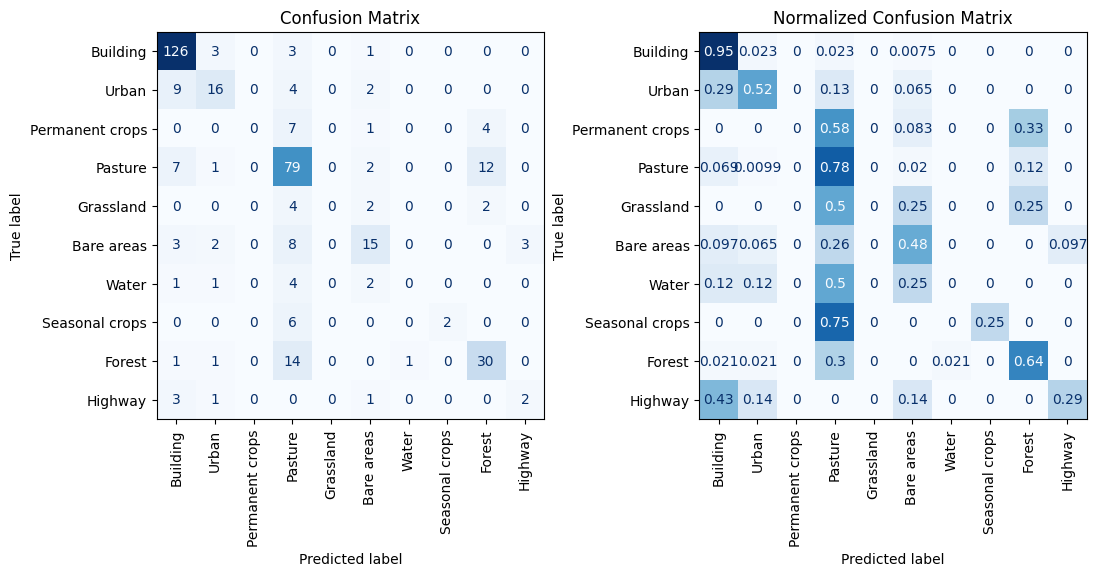

Overall Accuracy : 0.6994818652849741
                 precision    recall  f1-score   support

     Bare areas       0.58      0.48      0.53        31
       Building       0.84      0.95      0.89       133
         Forest       0.62      0.64      0.63        47
      Grassland       1.00      0.00      0.00         8
        Highway       0.40      0.29      0.33         7
        Pasture       0.61      0.78      0.69       101
Permanent crops       1.00      0.00      0.00        12
 Seasonal crops       1.00      0.25      0.40         8
          Urban       0.64      0.52      0.57        31
          Water       0.00      0.00      0.00         8

       accuracy                           0.70       386
      macro avg       0.67      0.39      0.40       386
   weighted avg       0.70      0.70      0.67       386



In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

overall,classification = compute_accuracy(rf, test_gdf[features], test_gdf[target], train_gdf)
print("Overall Accuracy :",overall) 
print(classification) 

Even though it is quite high `0.7`, the overall accuracy is not the most appropriate metric to evaluate the model as the dataset is imbalanced as seen in the [distribution notebook](./distribution.ipynb). We will use precision, recall and F1-score for each class to evaluate the model performance, as well as the macro-averaged F1-score.

On the normalized confusion matrix above, we can see that the model performs well on the `Building`, `Urban` classes. However, some classes are never or very little predicted such as `Permanent crops`, `Water`, `Seasonal crops`.
This may be explained by the similarity of features between these classes and other more represented classes in the dataset. For example, `Grass land` true labels are often predicted as `Pastures`, which is understandable as both classes may have similar pixel statistics.

In [ ]:
# Box plot of features stat per class
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import os

data_path = os.path.join(os.getcwd(), '..', 'data', 'geojson', 'train_files.geojson')
train_gdf = gpd.read_file(data_path)
features = ['r_mean','r_median', 'r_std','r_var', 'g_mean','g_median', 'g_std','g_var', 'b_mean','b_median','b_var', 'b_std']

### Hyperparameter Tuning using Grid Search Cross Validation

Fitting 10 folds for each of 16 candidates, totalling 160 fits
Best Hyperparameters: {'max_depth': 20, 'n_estimators': 200}


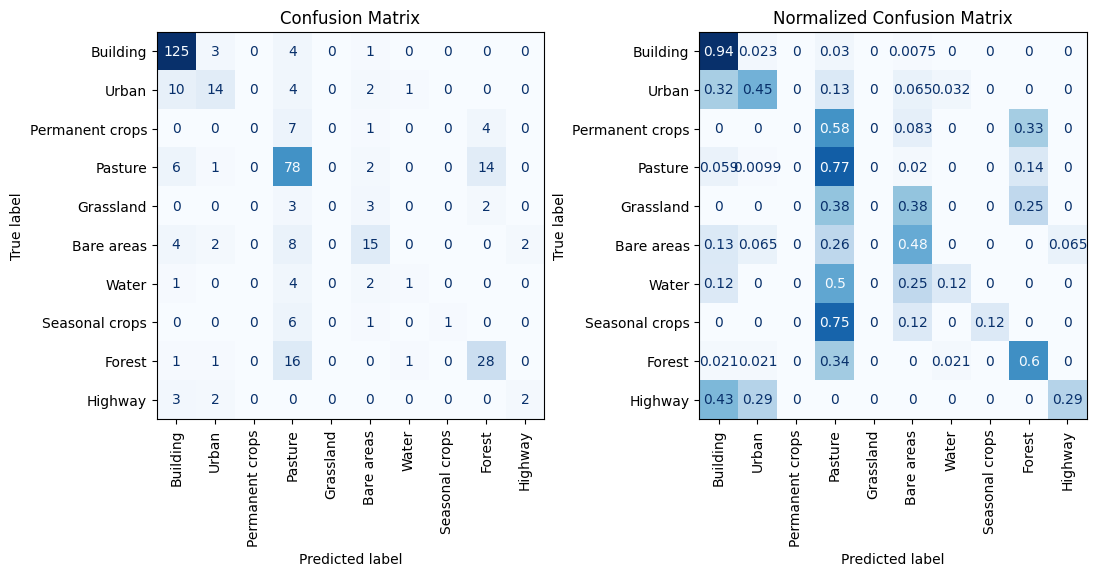

Overall Accuracy after Hyperparameter Tuning: 0.6839378238341969
                 precision    recall  f1-score   support

     Bare areas       0.56      0.48      0.52        31
       Building       0.83      0.94      0.88       133
         Forest       0.58      0.60      0.59        47
      Grassland       1.00      0.00      0.00         8
        Highway       0.50      0.29      0.36         7
        Pasture       0.60      0.77      0.68       101
Permanent crops       1.00      0.00      0.00        12
 Seasonal crops       1.00      0.12      0.22         8
          Urban       0.61      0.45      0.52        31
          Water       0.33      0.12      0.18         8

       accuracy                           0.68       386
      macro avg       0.70      0.38      0.40       386
   weighted avg       0.70      0.68      0.65       386



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [10, 20, 30, 40],
}

grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), param_grid=param_grid, cv=10, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

best_rf_classifier = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)

# Get accuracy of best model
overall,classification = compute_accuracy(best_rf_classifier, X_test, y_test, train_gdf)
print("Overall Accuracy after Hyperparameter Tuning:", overall)
print(classification)

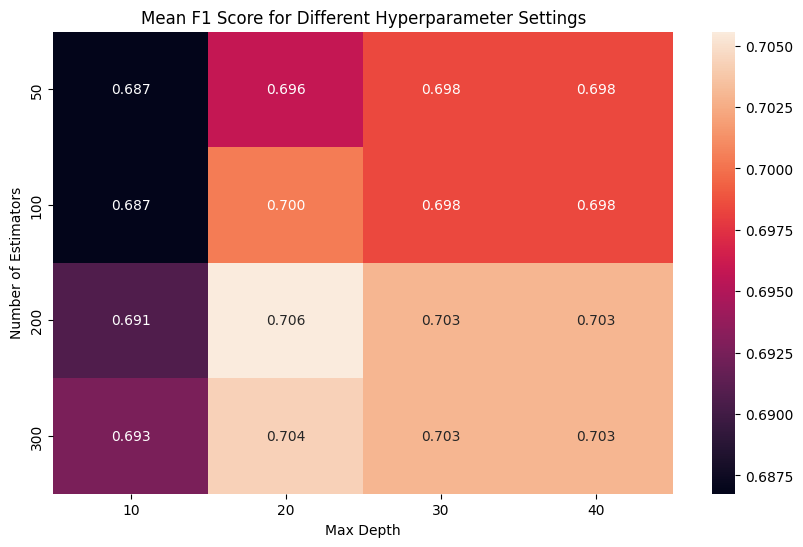

In [27]:
# Plot f1 score results over different hyperparameter settings
import pandas as pd
results = pd.DataFrame(grid_search.cv_results_)
pivot_table = results.pivot(index='param_n_estimators', columns='param_max_depth', values='mean_test_score')
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".3f")
plt.title("Mean F1 Score for Different Hyperparameter Settings")
plt.xlabel("Max Depth")
plt.ylabel("Number of Estimators")
plt.show()

In [66]:
print(rf.feature_importances_)

[0.06877956 0.06330281 0.04833977 0.046174   0.05881323 0.05775545
 0.06045662 0.05846614 0.0964636  0.07361275 0.08907687 0.08600709
 0.19275209]


In [67]:
mdi_importances = pd.Series(
    rf.feature_importances_, index=features
).sort_values(ascending=True)

In [68]:
mdi_importances

r_var       0.046174
r_std       0.048340
g_median    0.057755
g_var       0.058466
g_mean      0.058813
g_std       0.060457
r_median    0.063303
r_mean      0.068780
b_median    0.073613
b_std       0.086007
b_var       0.089077
b_mean      0.096464
area        0.192752
dtype: float64

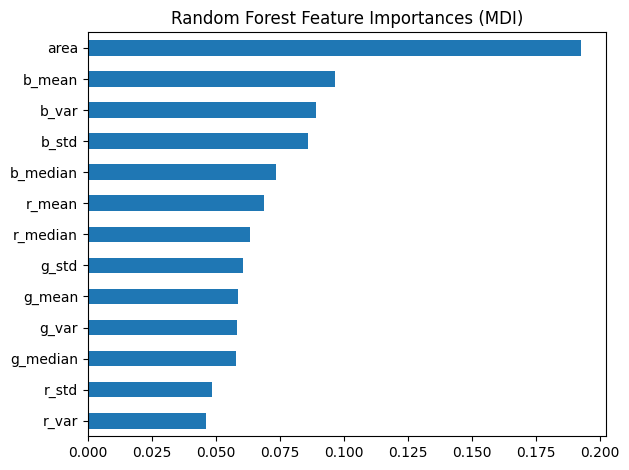

In [69]:
ax = mdi_importances.plot.barh()
ax.set_title("Random Forest Feature Importances (MDI)")
ax.figure.tight_layout()

In [ ]:
from sklearn.ensemble import BaggingClassifier

bc= BaggingClassifier(n_estimators=100,random_state=32) 

bc.fit(X_train, y_train)

,estimator,None
,n_estimators,100
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,32
,verbose,0


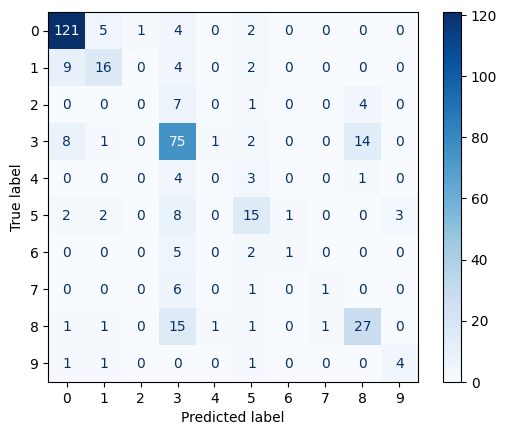

Overall Accuracy : 0.6735751295336787
              precision    recall  f1-score   support

           0       0.85      0.91      0.88       133
          11       0.62      0.52      0.56        31
          12       0.57      0.57      0.57         7
          21       0.50      0.12      0.20         8
          22       0.00      0.00      0.00        12
          23       0.59      0.74      0.66       101
          31       0.59      0.57      0.58        47
          32       0.00      0.00      0.00         8
          33       0.50      0.48      0.49        31
          51       0.50      0.12      0.20         8

    accuracy                           0.67       386
   macro avg       0.47      0.40      0.41       386
weighted avg       0.64      0.67      0.65       386



In [72]:
overall,classification = compute_accuracy(bc)
print("Overall Accuracy :",overall) 
print(classification) 

### Pipeline for preprocessing and modeling

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [20, 30, 40],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv,
    n_jobs=-1,
    verbose=2,
    scoring='f1_macro'
)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [20, 30, ...], 'n_estimators': [100, 200, ...]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [17]:
from sklearn.metrics import classification_report

best_model = grid_search.best_estimator_
print("Best Hyperparameters:", grid_search.best_params_)

from sklearn.model_selection import cross_val_score

scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='f1_macro')
print("Cross-validation scores:", scores)
print("%0.2f f1_macro with a standard deviation of %0.2f" % (scores.mean(), scores.std()))

y_pred = best_model.predict(X_test)

# Get accuracy of best model
print(classification_report(y_test, y_pred, target_names=label_map.values()))

Best Hyperparameters: {'max_depth': 30, 'n_estimators': 200}
Cross-validation scores: [0.42060366 0.37646848 0.33942624 0.36610804 0.37278083]
0.38 f1_macro with a standard deviation of 0.03
                 precision    recall  f1-score   support

       Building       0.54      0.42      0.47        31
          Urban       0.84      0.94      0.89       133
        Highway       0.59      0.62      0.60        47
 Seasonal crops       0.00      0.00      0.00         8
Permanent crops       0.40      0.29      0.33         7
        Pasture       0.60      0.77      0.67       101
         Forest       0.00      0.00      0.00        12
      Grassland       1.00      0.12      0.22         8
     Bare areas       0.62      0.52      0.56        31
          Water       0.00      0.00      0.00         8

       accuracy                           0.68       386
      macro avg       0.46      0.37      0.38       386
   weighted avg       0.64      0.68      0.65       386



C:\Users\elouann\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\elouann\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\elouann\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics

In [18]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

macro_f1 = f1_score(y_test, y_pred, average='macro')
print(f"Macro F1-Score: {macro_f1:.4f}")

Macro F1-Score: 0.3753


### Per-class Feature Importance Analysis

In [ ]:
import numpy as np
import pandas as pd

model = best_model
feature_names = features
class_feature_importance = {cls: np.zeros(len(feature_names)) for cls in model.classes_}

# Iterate over all trees in the forest
for tree in model.estimators_:
    children_left = tree.tree_.children_left
    children_right = tree.tree_.children_right
    feature = tree.tree_.feature
    value = tree.tree_.value  # Class probabilities at each node
    n_node_samples = tree.tree_.n_node_samples

    # Stack to keep track of nodes to visit: (node_id, weight, path_features)
    stack = [(0, 1.0, [])]  # (node_id, sample_weight, list of features used in path)

    while stack:
        node_id, weight, path_features = stack.pop()

        # If it's a leaf node
        if children_left[node_id] == children_right[node_id]:
            # Get the class probabilities at the leaf
            class_probs = value[node_id][0]
            # Get the dominant class at the leaf
            dominant_class_idx = np.argmax(class_probs)
            dominant_class = model.classes_[dominant_class_idx]
            # Accumulate the weight for the dominant class and path features
            for feature_idx in path_features:
                class_feature_importance[dominant_class][feature_idx] += weight
        else:
            # Push right and left children onto the stack with updated weights and path features
            # Update path_features for children
            current_feature = feature[node_id]
            stack.append((children_right[node_id], weight * n_node_samples[children_right[node_id]] / n_node_samples[node_id], path_features + [current_feature]))
            stack.append((children_left[node_id], weight * n_node_samples[children_left[node_id]] / n_node_samples[node_id], path_features + [current_feature]))

# Normalize the importance for each class
for cls in class_feature_importance:
    total = np.sum(class_feature_importance[cls])
    if total > 0:
        class_feature_importance[cls] /= total

# Convert to a DataFrame for readability
feature_importance_df = pd.DataFrame(
    {cls: class_feature_importance[cls] for cls in class_feature_importance},
    index=feature_names
)

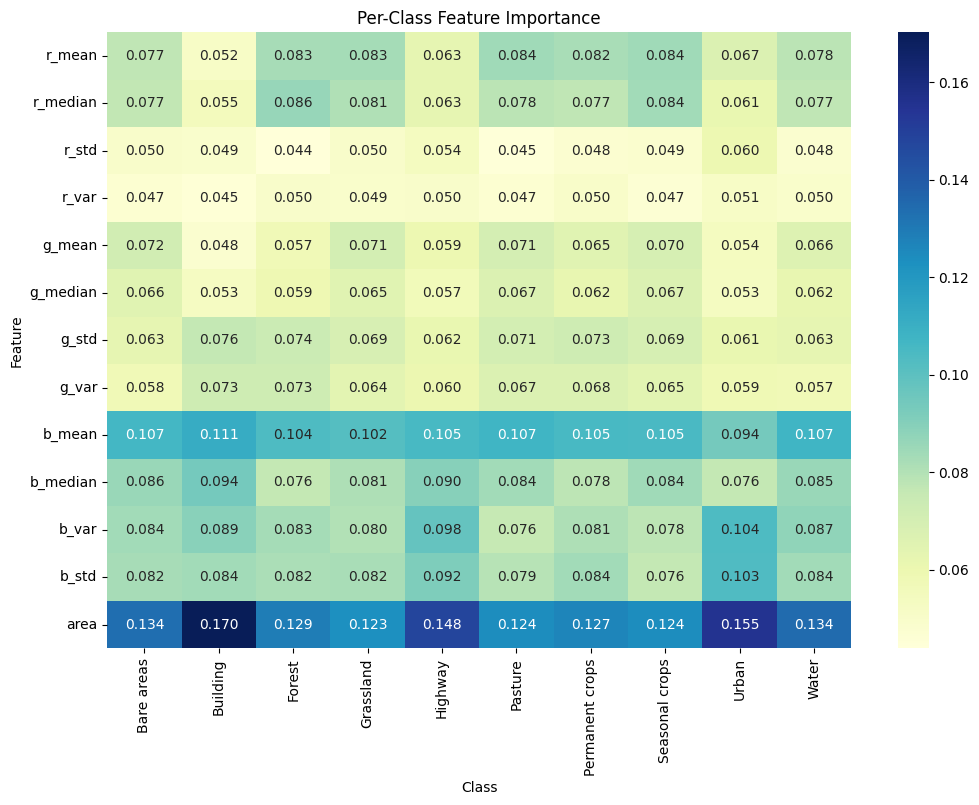

In [28]:
plt.figure(figsize=(12, 8))
sns.heatmap(feature_importance_df, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("Per-Class Feature Importance")
plt.xlabel("Class")
plt.ylabel("Feature")
plt.show()